# Notebook 83 — TimTrack alpha measurement-chain audit

This notebook checks whether the forward-alpha measurement gap mostly comes from Python's raw TimTrack alpha itself or from the later persistence/selection layer.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_timtrack_alpha_measurement_chain.py'
OUT = ROOT / 'results' / 'notebook83_timtrack_alpha_measurement_chain'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_timtrack_alpha_measurement_chain.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook83_timtrack_alpha_measurement_chain


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

# Notebook 83 — TimTrack alpha measurement-chain audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook follows the measurement side deeper: it compares Python raw TimTrack alpha, Python selected/persisted alpha, and MATLAB geofeature alpha, then tests whether the persistence/selection stage is the main cause of the forward alpha gap.

## Measurement-chain findings

- Python raw TimTrack alpha differs from MATLAB geofeature alpha by RMSE 2.8086 deg.
- Python selected/persisted alpha differs from MATLAB geofeature alpha by RMSE 2.7930 deg.
- The persistence/selection stage changes the raw alpha on only 21 of 2666 aligned frames, with selected-vs-raw RMSE 0.9293 deg.

## Notebook-only Kalman measurement swaps

- With the current Python prior, using selected/persisted alpha gives final alpha RMSE 1.1661 deg and FL RMSE 2.0117 mm.
- Replacing selected alpha with raw TimTrack alpha barely changes the result: final alpha RMSE becomes 1.1298 deg and FL RMSE 1.9521 mm.


CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_timtrack_alpha_measurement_chain.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook83_summary.md').read_text()))

# Notebook 83 — TimTrack alpha measurement-chain audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook follows the measurement side deeper: it compares Python raw TimTrack alpha, Python selected/persisted alpha, and MATLAB geofeature alpha, then tests whether the persistence/selection stage is the main cause of the forward alpha gap.

## Measurement-chain findings

- Python raw TimTrack alpha differs from MATLAB geofeature alpha by RMSE 2.8086 deg.
- Python selected/persisted alpha differs from MATLAB geofeature alpha by RMSE 2.7930 deg.
- The persistence/selection stage changes the raw alpha on only 21 of 2666 aligned frames, with selected-vs-raw RMSE 0.9293 deg.

## Notebook-only Kalman measurement swaps

- With the current Python prior, using selected/persisted alpha gives final alpha RMSE 1.1661 deg and FL RMSE 2.0117 mm.
- Replacing selected alpha with raw TimTrack alpha barely changes the result: final alpha RMSE becomes 1.1298 deg and FL RMSE 1.9521 mm.
- Replacing the measurement with MATLAB geofeature alpha is the meaningful jump: final alpha RMSE becomes 0.5470 deg and FL RMSE 1.1810 mm.

## Interpretation

- The Python persistence/selection layer is not the dominant problem in this run.
- The main mismatch is already present in the raw TimTrack alpha entering that layer.
- That means the next useful audit target is earlier in the TimTrack/Hough alpha-production chain itself: image/mask inputs, candidate generation, or angle convention before persistence even has a chance to help.

- Measurement metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook83_timtrack_alpha_measurement_chain/measurement_chain_metrics.csv`
- Per-frame change CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook83_timtrack_alpha_measurement_chain/timtrack_alpha_changes.csv`
- Variant metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook83_timtrack_alpha_measurement_chain/measurement_chain_variants.csv`
- Trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook83_timtrack_alpha_measurement_chain/measurement_chain_traces.png`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook83_timtrack_alpha_measurement_chain/measurement_chain_summary.png`


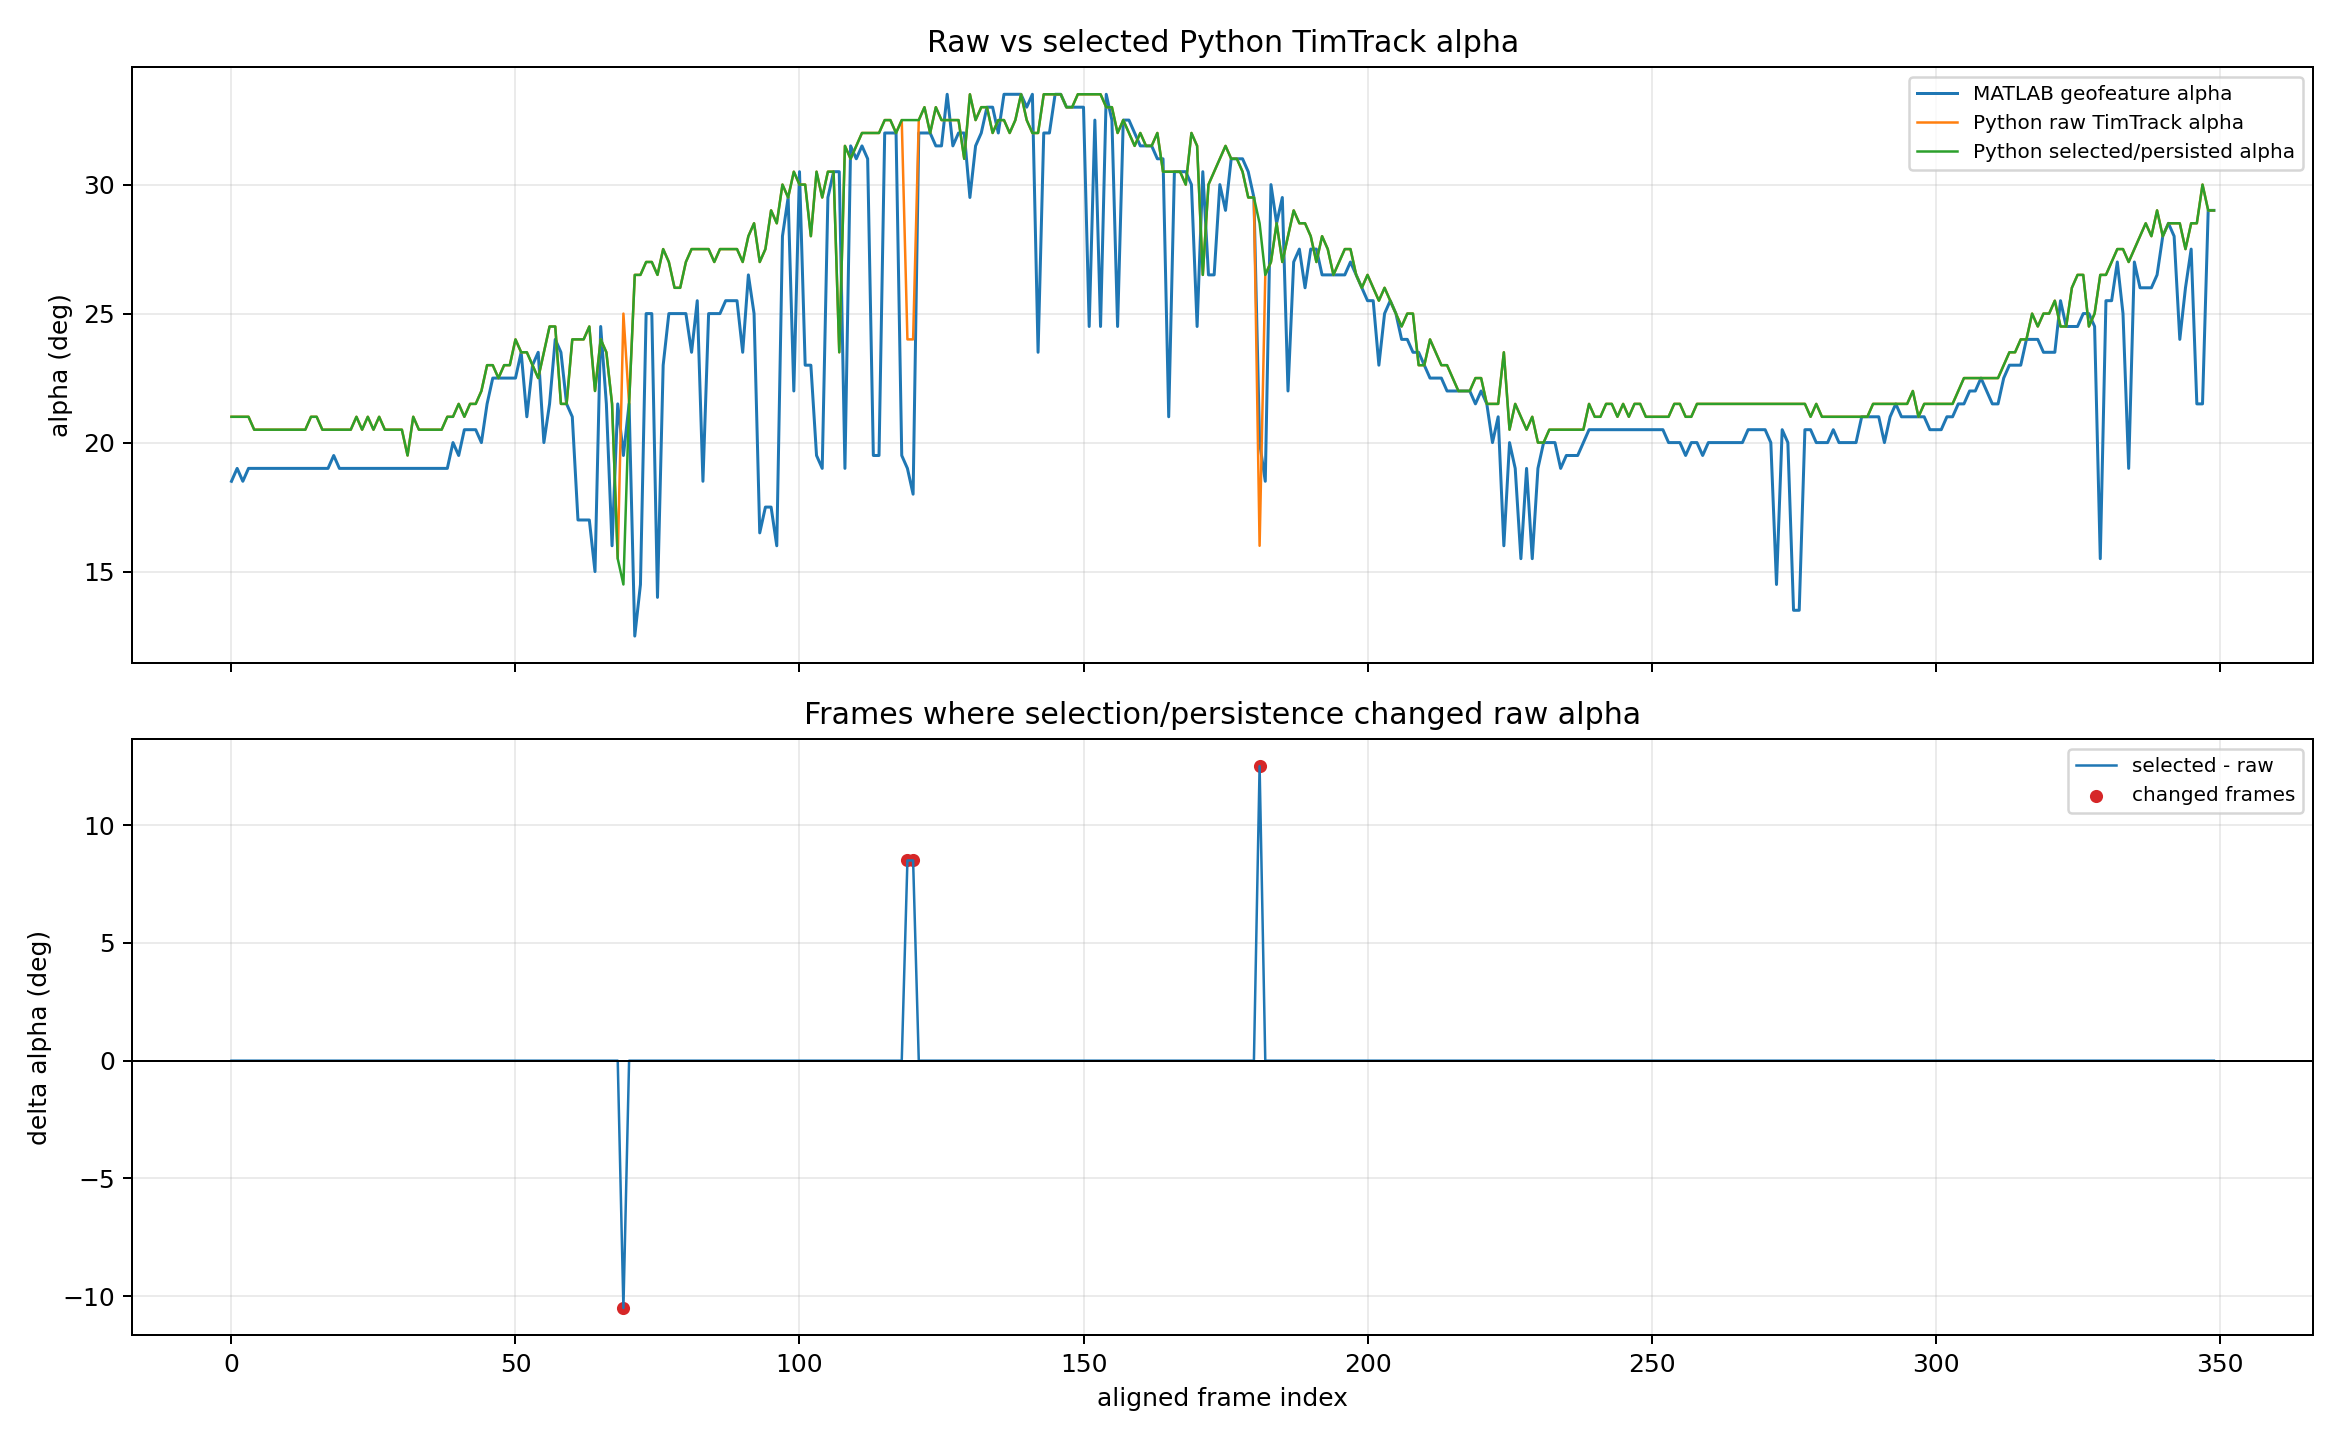

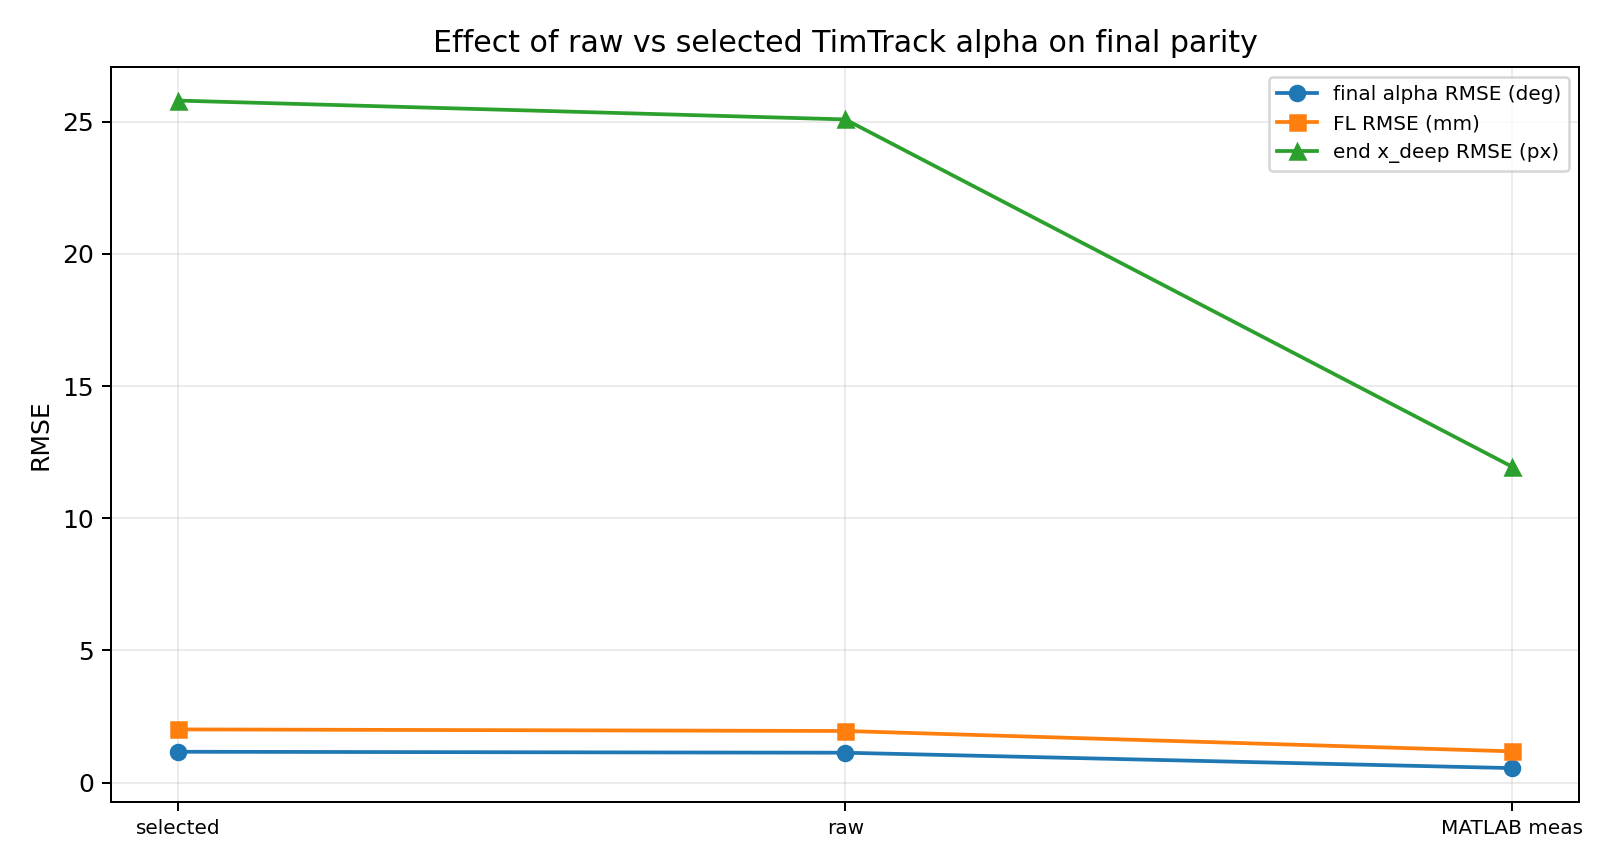

In [4]:
display(Image(filename=str(OUT / 'measurement_chain_traces.png')))
display(Image(filename=str(OUT / 'measurement_chain_summary.png')))